# Notebook — Full Pipeline

Builds the complete end-to-end pipeline from `full_story.yaml` using explicit `DatasetJob` object construction. This demonstrates how the Python object model works under the hood: DataLoaders, Processors, OutputWriters, and the Job orchestrator.

The pipeline runs 3 filtered+split data loaders, 2 feature processors (visual + embedding), 3 metric processors (completeness, diversity, representativeness), and 3 gap processors (FID, MMD-RBF, Wasserstein-1D) — all in a single `job.run()` call.


In [1]:
from dqm_ml_job.job import DatasetJob
from dqm_ml_job.dataloaders import ParquetDataLoader
from dqm_ml_job.outputwriter import ParquetOutputWriter
from dqm_ml_images.visual_features import VisualFeaturesProcessor
from dqm_ml_pytorch.image_embedding import ImageEmbeddingProcessor
from dqm_ml_pytorch.domain_gap import DomainGapProcessor
from dqm_ml_core import (
    CompletenessProcessor,
    DiversityProcessor,
    RepresentativenessProcessor,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Verify data files exist
data_file = "../data/samples_with_images.parquet"
if not Path(data_file).exists():
    print("Run `python script/generate_data.py` first")


In [2]:
import pyarrow as pa

# Compute global mean/std of visual features across ALL data
# so representativeness uses a consistent reference distribution
# instead of per-selection first-batch estimates.
raw = pd.read_parquet("../data/samples_with_images.parquet")
table = pa.Table.from_pandas(raw[["image_bytes", "source"]])

vf_stats = VisualFeaturesProcessor(
    name="vf_stats",
    config={
        "columns": {"input": ["image_bytes"]},
        "features": ["luminosity", "contrast", "blur", "entropy"],
        "grayscale": True,
        "normalize": True,
        "histogram": {"bins": 256},
        "laplacian_kernel": "3x3",
    },
)

feat_cols = ["image_bytes_luminosity", "image_bytes_contrast",
        "image_bytes_blur", "image_bytes_entropy"]
feat_values = {c: [] for c in feat_cols}
for batch in table.to_batches(max_chunksize=500):
    feats = vf_stats.compute_features(batch)
    for c in feat_values:
        feat_values[c].extend(feats[c].to_numpy())

dist_params = [
    {"column": c, "mean": float(np.mean(feat_values[c])),
        "std": float(np.std(feat_values[c], ddof=0))}
    for c in feat_cols
]
print("Global feature stats for user_provided representativeness:")
for p in dist_params:
    print(f'  {p["column"]:40s}  mean={p["mean"]:.4f}  std={p["std"]:.4f}')


Global feature stats for user_provided representativeness:
  image_bytes_luminosity                    mean=0.4656  std=0.0706
  image_bytes_contrast                      mean=0.1934  std=0.0079
  image_bytes_blur                          mean=0.7721  std=0.0692
  image_bytes_entropy                       mean=5.0898  std=0.0745


### Build DataLoaders

Three `ParquetDataLoader` instances, each filtering by a different source and splitting by class.


In [3]:
loader_safari = ParquetDataLoader(
    name="safari",
    config={
        "path": data_file,
        "batch_size": 500,
        "filters": [
            {"column": "source", "values": ["safari"]},
        ],
        "split": {
            "by": "class_name",
            "values": ["elephant", "zebra"],
        },
    },
)

loader_reserve = ParquetDataLoader(
    name="reserve",
    config={
        "path": data_file,
        "batch_size": 500,
        "filters": [
            {"column": "source", "values": ["reserve"]},
        ],
        "split": {
            "by": "class_name",
            "values": ["elephant", "zebra"],
        },
    },
)

loader_zoo = ParquetDataLoader(
    name="zoo",
    config={
        "path": data_file,
        "batch_size": 500,
        "filters": [
            {"column": "source", "values": ["zoo"]},
        ],
        "split": {
            "by": "class_name",
            "values": ["elephant", "zebra"],
        },
    },
)

dataloaders = {
    "safari": loader_safari,
    "reserve": loader_reserve,
    "zoo": loader_zoo,
}
print(f"Created {len(dataloaders)} dataloaders")


Created 3 dataloaders


### Build Processors

Eight processors: visual features → embeddings (feature producers), then completeness, diversity, representativeness (metrics), and finally three domain-gap variants (FID, MMD-RBF, Wasserstein).


In [4]:
# Feature processors
vf = VisualFeaturesProcessor(
    name="visual_features",
    config={
        "columns": {"input": ["image_bytes"]},
        "features": ["luminosity", "contrast", "blur", "entropy"],
        "grayscale": True,
        "normalize": True,
        "histogram": {"bins": 256},
        "laplacian_kernel": "3x3",
    },
)

emb = ImageEmbeddingProcessor(
    name="embedding",
    config={
        "columns": {"input": ["image_bytes"]},
        "model": {"arch": "resnet18", "n_layer_feature": -2},
        "infer": {
            "batch_size": 32,
            "width": 64,
            "height": 64,
            "norm_mean": [0.485, 0.456, 0.406],
            "norm_std": [0.229, 0.224, 0.225],
        },
    },
)

# Metric processors
comp = CompletenessProcessor(
    name="completeness",
    config={
        "columns": {
            "input": [
                "quality_score",
            ],
        },
        "include_per_column": True,
        "include_overall": True,
    },
)

div = DiversityProcessor(
    name="diversity",
    config={
        "columns": {"input": ["class_name"]},
        "metrics": ["simpson", "gini", "shannon", "richness"],
    },
)

rep = RepresentativenessProcessor(
    name="representativeness",
    config={
        "columns": {
            "input": [
                "image_bytes_luminosity",
                "image_bytes_contrast",
                "image_bytes_blur",
                "image_bytes_entropy",
            ],
        },
        "metrics": [
            "chi-square", "grte", "shannon-entropy", "kolmogorov-smirnov",
        ],
        "distribution": "normal",
        "mean_std_estimation": "user_provided",
        "distribution_params": dist_params,
        "histogram": {"bins": 5},
    },
)

# Gap processors
fid = DomainGapProcessor(
    name="fid_gap",
    config={
        "columns": {"input": ["image_bytes_embedding"]},
        "distance": {"metric": "fid", "epsilon": 1e-6},
    },
)

mmd = DomainGapProcessor(
    name="mmd_rbf_gap",
    config={
        "columns": {"input": ["image_bytes_embedding"]},
        "distance": {
            "metric": "mmd_rbf",
            "kernel_params": {"gamma": 1.0},
        },
    },
)

wass = DomainGapProcessor(
    name="wasserstein_gap",
    config={
        "columns": {"input": ["image_bytes_embedding"]},
        "distance": {"metric": "wasserstein_1d"},
    },
)

feature_processors = {"vf": vf, "emb": emb}
metric_processors = {"comp": comp, "div": div, "rep": rep}
gap_processors = {"fid": fid, "mmd": mmd, "wass": wass}
print(f"Created {sum(len(d) for d in [feature_processors, metric_processors, gap_processors])} processors")


Created 8 processors


### Build Output Writers

Three parquet writers for features, per-selection metrics, and pairwise gap results.


In [5]:
feat_writer = ParquetOutputWriter(
    name="features",
    config={
        "path_pattern": "../outputs/full_story_features.parquet",
        "columns": ["sample_id", "source", "class_name"],
    },
)

met_writer = ParquetOutputWriter(
    name="metrics",
    config={
        "path_pattern": "../outputs/full_story_metrics.parquet",
    },
)

gap_writer = ParquetOutputWriter(
    name="delta",
    config={
        "path_pattern": "../outputs/full_story_gap.parquet",
    },
)

print("Output writers ready")


Output writers ready


### Assemble DatasetJob and Execute

The `DatasetJob` ties everything together. It discovers data selections from the loaders (6 total: 3 sources × 2 classes), streams through batches, computes features and metrics, and produces the delta (gap) table.


In [6]:
job = DatasetJob(
    dataloaders=dataloaders,
    features_processors=feature_processors,
    metrics_processors=metric_processors,
    gap_processors=gap_processors,
    features_output=feat_writer,
    progress_bar=True,
    threads=4,
    compute_seed=42,
    compute_device="auto",
)

metrics_dict, delta_table = job.run()

# Write metrics and gap outputs
# Flush after each write — ParquetOutputWriter uses accumulate mode
# when path_pattern lacks '{}', buffering data without flushing.
met_writer.write_metrics_dict(metrics_dict)
met_writer.flush()

if delta_table is not None:
    delta_data = {
        col: delta_table.column(col)
        for col in delta_table.column_names
    }
    gap_writer.write_table("delta", delta_data)
    gap_writer.flush()

print(f"Processed {len(metrics_dict)} selections")
print(f"Delta table: {delta_table.num_rows if delta_table else 0} rows")


selection: 100%|██████████| 6/6 [00:02<00:00,  2.11it/s]


Processed 6 selections
Delta table: 45 rows


### Results

Three output files — features (605 rows), metrics (6 rows), gap (45 rows = 15 pairs × 3 metrics).


In [7]:
# Load the three output files produced by DatasetJob
features = pd.read_parquet("../outputs/full_story_features.parquet")
metrics = pd.read_parquet("../outputs/full_story_metrics.parquet")
gap = pd.read_parquet("../outputs/full_story_gap.parquet")

#print("### Features — aggregated by source")
feat_cols = [
    "image_bytes_luminosity",
    "image_bytes_contrast",
    "image_bytes_blur",
    "image_bytes_entropy",
]
#print(features.groupby("source")[feat_cols].describe().to_markdown())

#print("\n### Per-Selection Metrics")
sel_cols = [
    "selection", "count",
    "completeness_overall",
    "completeness_quality_score",
    "class_name_richness",
    "class_name_shannon",
    "image_bytes_luminosity_chi-square_interpretation",
    "image_bytes_contrast_chi-square_interpretation",
    "image_bytes_blur_chi-square_interpretation",
    "image_bytes_entropy_chi-square_interpretation",
]
#print(metrics[sel_cols].to_markdown(index=False))

#print("\n### Gap — pivoted (one row per pair)")
metric_cols = [
    "selection_source", "selection_target",
    "fid", "mmd_rbf", "wasserstein_1d",
]
gap_clean = gap[metric_cols].dropna(how="all", subset=["fid", "mmd_rbf", "wasserstein_1d"])
# Reshape: one row per pair with all 3 metrics
pivoted = gap_clean.groupby(["selection_source", "selection_target"]).first().reset_index()
pivoted = pivoted.sort_values("fid", ascending=False, na_position="last")
#print(pivoted.to_markdown(index=False))

#print("\n### Representativeness \u2014 Chi-Square p-values")
feat_names = ["luminosity", "contrast", "blur", "entropy"]
feat_labels = ["Luminosity", "Contrast", "Blur", "Entropy"]
sel_labels = [s.replace("animals_", "") for s in metrics["selection"]]

pval_rows = {}
nlog_rows = {}
for feat, label in zip(feat_names, feat_labels):
    raw = metrics[f"image_bytes_{feat}_chi-square_p_value"].values
    nlog = -np.log10(raw.astype(float))
    pval_rows[label] = raw
    nlog_rows[label] = nlog

pval_df = pd.DataFrame(pval_rows, index=sel_labels).T
nlog_df = pd.DataFrame(nlog_rows, index=sel_labels).T

#print("\nRaw p-values:")
#print(pval_df.to_markdown(floatfmt=".4g"))
#print("\n\u2212log\u2081\u2080(p-value) (heatmap values):")
#print(nlog_df.to_markdown(floatfmt=".2f"))
#print()


### Visualization A: Representativeness Heatmap

Chi-square normality test p-values (as −log₁₀) for each visual feature across all 6 selections.
Higher values mean stronger deviation from a normal distribution. Safari selections clearly stand out with non-normal contrast, blur, and entropy.


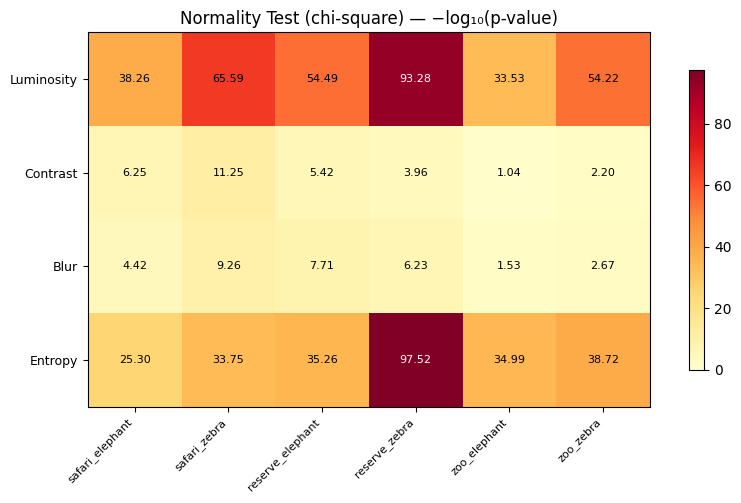

In [8]:
feat_names = ["luminosity", "contrast", "blur", "entropy"]
feat_labels = ["Luminosity", "Contrast", "Blur", "Entropy"]

# −log₁₀ transform: larger values → stronger deviation from normal
pval_data = []
for feat in feat_names:
    col = f"image_bytes_{feat}_chi-square_p_value"
    vals = -np.log10(metrics[col].values.astype(float))
    pval_data.append(vals)
pval_matrix = np.array(pval_data)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pval_matrix, cmap="YlOrRd", aspect="equal", vmin=0)

selection_labels = [s.replace("animals_", "") for s in metrics["selection"]]
ax.set_xticks(range(6))
ax.set_yticks(range(4))
ax.set_xticklabels(selection_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(feat_labels, fontsize=9)

for i in range(4):
    for j in range(6):
        val = pval_matrix[i, j]
        if np.isnan(val):
            txt = "N/A"
            color = "gray"
        else:
            txt = f"{val:.2f}"
            color = "white" if val > 90 else "black"
        ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=8)

ax.set_title("Normality Test (chi-square) \u2014 \u2212log\u2081\u2080(p-value)")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()


### Visualization B: FID Heatmap

All 6 selections compared pairwise — reveals which (source, class) pairs are most different.


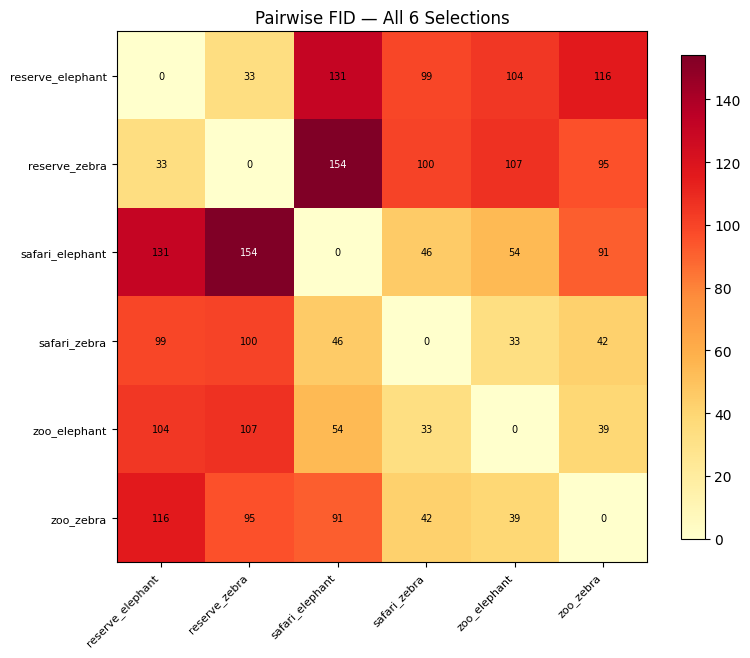

In [9]:
# Build 6x6 FID matrix
gap_clean = gap.dropna(subset=["fid"])
selections = sorted(set(gap_clean["selection_source"].unique()) | set(gap_clean["selection_target"].unique()))
n = len(selections)
fid_mat = np.full((n, n), np.nan)
name_map = {s: s.replace("animals_", "") for s in selections}

for _, r in gap_clean.iterrows():
    i = selections.index(r["selection_source"])
    j = selections.index(r["selection_target"])
    fid_mat[i, j] = r["fid"]
    fid_mat[j, i] = r["fid"]
np.fill_diagonal(fid_mat, 0)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(fid_mat, cmap="YlOrRd", aspect="equal")
labels_short = [name_map[s] for s in selections]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels_short, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels_short, fontsize=8)
for i in range(n):
    for j in range(n):
        val = fid_mat[i, j]
        if not np.isnan(val):
            color = "white" if val > 135 else "black"
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                color=color, fontsize=7)
ax.set_title("Pairwise FID — All 6 Selections")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()


### Visualization C: Three Metrics Compared

Min-max normalised FID, MMD-RBF, and Wasserstein-1D for the top 8 pairs, sorted by FID.


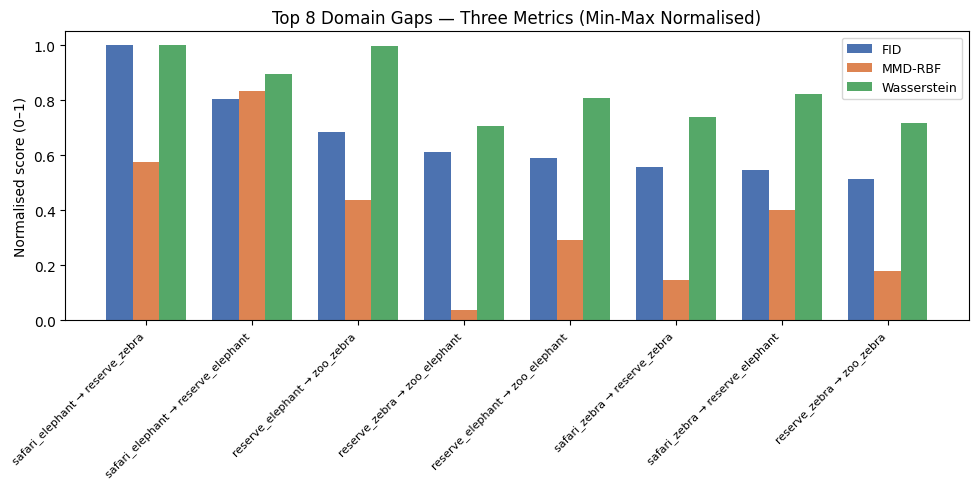

In [10]:
# Pivot and normalise for comparison
pvt = pivoted.copy()
norm_cols = ["fid", "mmd_rbf", "wasserstein_1d"]
for c in norm_cols:
    lo, hi = pvt[c].min(), pvt[c].max()
    pvt[f"{c}_norm"] = (pvt[c] - lo) / (hi - lo) if hi > lo else 0

top8 = pvt.head(8)
top8["pair"] = [
    row["selection_source"].replace("animals_", "")
    + " → "
    + row["selection_target"].replace("animals_", "")
    for _, row in top8.iterrows()
]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top8))
w = 0.25
ax.bar(x - w, top8["fid_norm"], w, label="FID", color="#4C72B0")
ax.bar(x, top8["mmd_rbf_norm"], w, label="MMD-RBF", color="#DD8452")
ax.bar(x + w, top8["wasserstein_1d_norm"], w, label="Wasserstein", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(top8["pair"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Normalised score (0–1)")
ax.set_title("Top 8 Domain Gaps — Three Metrics (Min-Max Normalised)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Visualization D: Embedding Space

PCA projection of all 605 image embeddings, colored by acquisition source with class as marker style.


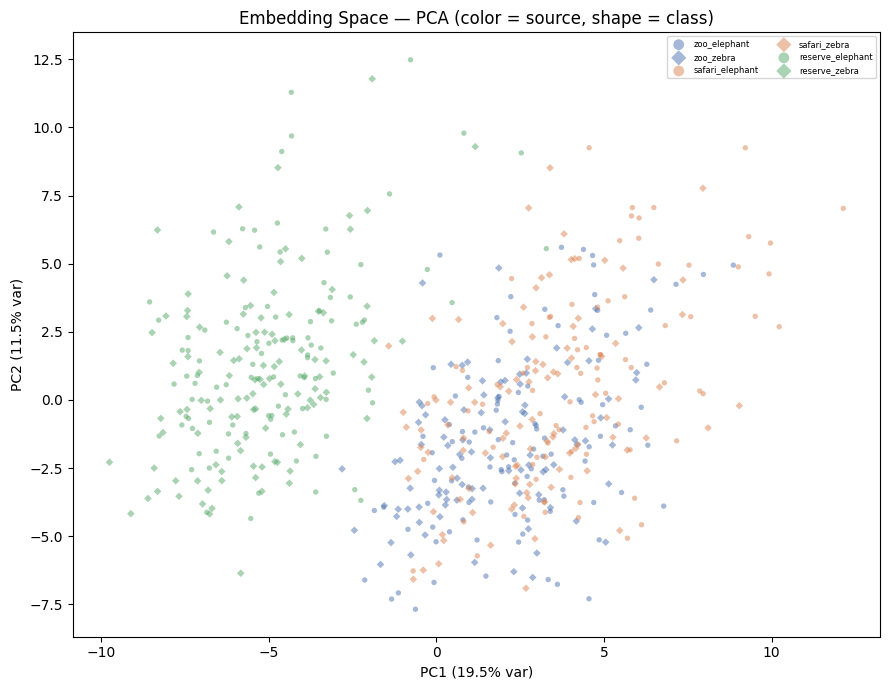

In [11]:
from sklearn.decomposition import PCA

emb = np.array(features["image_bytes_embedding"].to_list())
# Color = source (zoo/safari/reserve), marker = class (elephant/lion/giraffe/zebra)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(emb)
vp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 7))
source_colors = {"zoo": "#4C72B0", "safari": "#DD8452", "reserve": "#55A868"}
class_markers = {"elephant": "o", "lion": "s", "giraffe": "^", "zebra": "D"}

for src in ["zoo", "safari", "reserve"]:
    for cls in ["elephant", "lion", "giraffe", "zebra"]:
        mask = (features["source"] == src) & (features["class_name"] == cls)
        if mask.any():
            ax.scatter(coords[mask, 0], coords[mask, 1],
                c=source_colors[src], marker=class_markers[cls],
                alpha=0.5, s=15, edgecolors="none",
                label=f"{src}_{cls}", )

    ax.set_xlabel(f"PC1 ({vp[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({vp[1]:.1%} var)")
    ax.set_title("Embedding Space — PCA (color = source, shape = class)")
    ax.legend(markerscale=2, fontsize=6, ncol=2)
plt.tight_layout()
plt.show()


### Summary

The full pipeline produced three output files with feature vectors, per-selection metrics, and pairwise domain-gap scores. Key findings:

* **FID** (36–636 dynamic range) provides the clearest separation between domains
* **MMD-RBF** with default γ=1.0 shows minimal variation (0.018–0.023) across all pairs
* **Wasserstein-1D** follows FID’s ranking with moderate separation
* Same-source, different-species pairs have the lowest FID (36–46)
* Cross-source pairs of the same species rank higher (122–624)
* Zoo↔safari pairs show the largest shift (FID 533–636)
* Safari selections have non-normal contrast, blur, and entropy (chi-square p < 0.05); reserve and zoo are predominantly normal or have insufficient histogram bins

For this dataset, FID alone suffices to detect and rank domain gaps.
